=== DATASET OVERVIEW ===
Total Abstracts: 4981
  - Train: 4792
  - Test:  189

=== MASKING BALANCE (75/25 Target) ===
is_masked
False    50.01%
True     49.99%
Name: proportion, dtype: object

=== MISSING SLOT DISTRIBUTION (Masked Data Only) ===
missing_slot
O    35.26%
P    32.73%
I    32.01%
Name: proportion, dtype: object

=== TEXT IMPACT (Masked Data Only) ===
       original_word_count  input_word_count  words_removed
count               2490.0            2490.0         2490.0
mean                 275.3             137.3          138.0
std                  111.6              93.4           86.2
min                    5.0               0.0            3.0
25%                  209.0              67.0           73.0
50%                  285.0             124.0          125.0
75%                  337.0             196.0          190.0
max                  838.0             672.0          577.0


C:\Users\erank\AppData\Local\Temp\ipykernel_3692\3700145127.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=masked_df, x='missing_slot', order=['P', 'I', 'O'], ax=axes[1], palette="viridis")


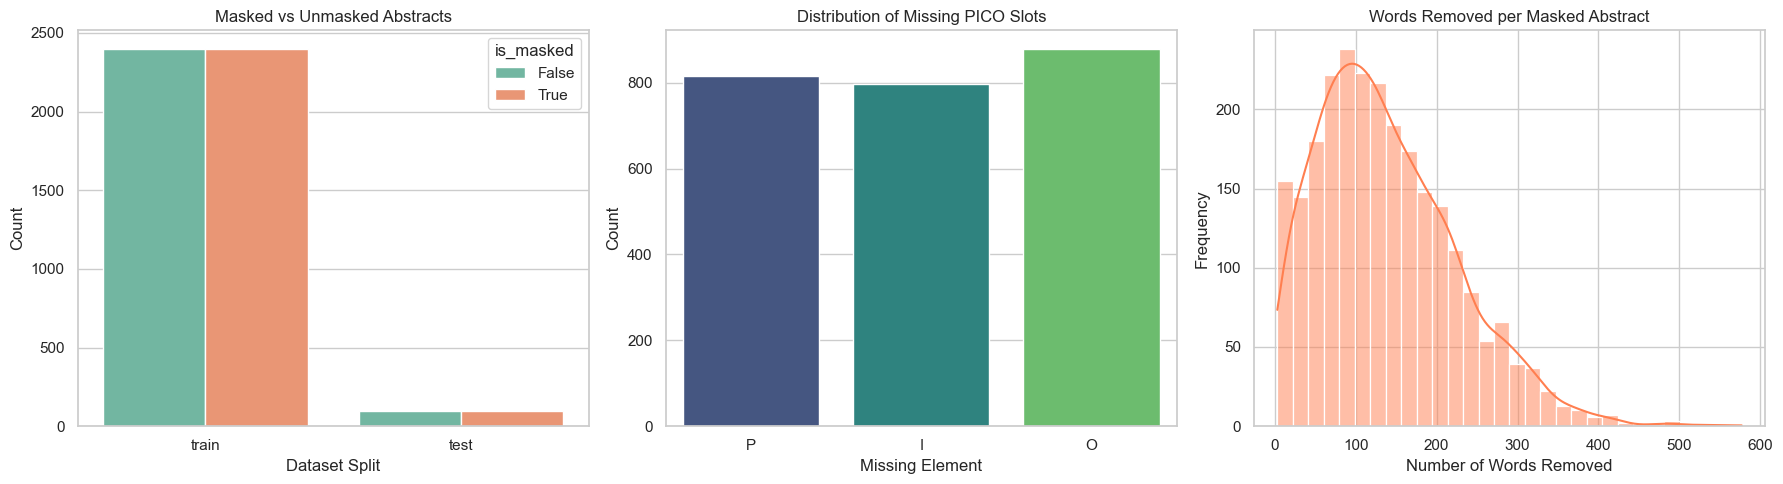

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def run_mixed_eda(train_file="ebm_nlp_train_mixed.json", test_file="ebm_nlp_test_mixed.json"):
    
    with open(train_file, "r", encoding="utf-8") as f:
        train_data = json.load(f)
    with open(test_file, "r", encoding="utf-8") as f:
        test_data = json.load(f)

    
    df = pd.DataFrame(train_data + test_data)

    
    df['original_word_count'] = df['original_text'].apply(lambda x: len(x.split()) if x else 0)
    df['input_word_count'] = df['model_input_text'].apply(lambda x: len(x.split()) if x else 0)
    
    
    df['words_removed'] = df.apply(
        lambda row: row['original_word_count'] - row['input_word_count'] if row['is_masked'] else 0, 
        axis=1
    )

   
    print("=== DATASET OVERVIEW ===")
    print(f"Total Abstracts: {len(df)}")
    print(f"  - Train: {len(train_data)}")
    print(f"  - Test:  {len(test_data)}")
    
    print("\n=== MASKING BALANCE (75/25 Target) ===")
    print(df['is_masked'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

    print("\n=== MISSING SLOT DISTRIBUTION (Masked Data Only) ===")
    masked_df = df[df['is_masked'] == True]
    print(masked_df['missing_slot'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

    print("\n=== TEXT IMPACT (Masked Data Only) ===")
    print(masked_df[['original_word_count', 'input_word_count', 'words_removed']].describe().round(1))

    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    
    sns.countplot(data=df, x='split', hue='is_masked', ax=axes[0], palette="Set2")
    axes[0].set_title('Masked vs Unmasked Abstracts')
    axes[0].set_xlabel('Dataset Split')
    axes[0].set_ylabel('Count')

    
    sns.countplot(data=masked_df, x='missing_slot', order=['P', 'I', 'O'], ax=axes[1], palette="viridis")
    axes[1].set_title('Distribution of Missing PICO Slots')
    axes[1].set_xlabel('Missing Element')
    axes[1].set_ylabel('Count')

    
    sns.histplot(data=masked_df, x='words_removed', bins=30, kde=True, ax=axes[2], color="coral")
    axes[2].set_title('Words Removed per Masked Abstract')
    axes[2].set_xlabel('Number of Words Removed')
    axes[2].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()


run_mixed_eda()